# Variant Effect Prediction with PEINT

This notebook shows how to use a trained PEINT model for **variant effect prediction (VEP)**
on deep mutational scanning (DMS) data.

PEINT scores a target sequence `y` given a source sequence `x` and an evolutionary time `t`.
For VEP we set the source `x` to the **wild-type** sequence, each target `y` to a **mutant**
sequence, and use `t = 1`. The per-residue negative log-likelihood (NLL) of a mutant is our
predicted variant effect: lower NLL (more probable under the model) corresponds to a more
wild-type-like, higher-fitness variant.

The `vep.ckpt` checkpoint is a lightweight PEINT model trained on top of ESM2.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

from protevo.models import load_peint_model

%matplotlib inline

/scratch/users/akoehl/conda/envs/protevo-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[2026-06-26 10:33:51,321] - cherryml.caching - INFO - Setting cache to use hash length: 64


[2026-06-26 10:33:51,322] - cherryml.caching - INFO - Setting cache to use 0 directory levels.


## Select a device

PEINT runs fastest on a CUDA GPU with Flash Attention (it uses encoder caching to evaluate
many mutants against one wild type). When Flash Attention is unavailable (e.g. CPU or Apple
MPS), `load_peint_model` automatically falls back to the standard-attention model and
`evaluate_likelihood` still works.

In [2]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f'Using device: {device}')

Using device: cuda


## Load the model

We load `vep.ckpt` as an **evaluator** (`model_type='evaluator'`), which exposes
`evaluate_likelihood`. On the first call the ESM2 backbone is downloaded from the public
release; the lightweight PEINT layers come from the checkpoint.

In [3]:
ckpt_file = Path('model_checkpoints') / 'vep.ckpt'
model, vocab = load_peint_model(ckpt_file, device=device, model_type='evaluator')

## Load the DMS data

`NRAM_I33A0_Jiang_2016.csv` is a deep mutational scan of neuraminidase. Each row is a single
mutant: the `mutant` column (e.g. `V67L`) gives the wild-type residue, 1-indexed position,
and mutant residue; `mutated_sequence` is the full mutant protein; `DMS_score` is the
measured fitness (higher = more fit).

In [4]:
vep_file = Path('NRAM_I33A0_Jiang_2016.csv')
df = pd.read_csv(vep_file)
print(f'{len(df)} variants')
df.head()

298 variants


,mutant,mutated_sequence,DMS_score,DMS_score_bin
0,V67L,MNPNQKIITIGSICMVVGIISLILQIGNIISIWISHSIQTGNQNHT...,0.029690,1
1,V67A,MNPNQKIITIGSICMVVGIISLILQIGNIISIWISHSIQTGNQNHT...,0.012077,1
2,V67E,MNPNQKIITIGSICMVVGIISLILQIGNIISIWISHSIQTGNQNHT...,-0.004282,1
3,V67G,MNPNQKIITIGSICMVVGIISLILQIGNIISIWISHSIQTGNQNHT...,-0.000374,1
4,V67M,MNPNQKIITIGSICMVVGIISLILQIGNIISIWISHSIQTGNQNHT...,-0.055520,1


## Reconstruct the wild-type sequence

Each `mutant` annotation tells us the wild-type residue at its position, so we can rebuild the
wild type from any mutant by reverting that single substitution. Doing this for every row
yields a single, consistent wild-type sequence (a good sanity check on the data).

In [5]:
def wild_type_from_mutant(mutant: str, mutated_sequence: str) -> str:
    """Revert a single substitution (e.g. 'V67L') to recover the wild-type sequence."""
    wt_aa, mut_aa = mutant[0], mutant[-1]
    idx = int(mutant[1:-1]) - 1  # annotations are 1-indexed
    assert mutated_sequence[idx] == mut_aa, f'{mutant}: expected {mut_aa} at position {idx + 1}'
    return mutated_sequence[:idx] + wt_aa + mutated_sequence[idx + 1:]

wild_types = {wild_type_from_mutant(m, s) for m, s in zip(df['mutant'], df['mutated_sequence'])}
assert len(wild_types) == 1, 'mutant annotations are inconsistent'
wt = wild_types.pop()
print(f'Wild-type length: {len(wt)}')

Wild-type length: 453


## Score the variants

We evaluate the likelihood of every mutant sequence given the wild type at `t = 1`. The
encoder is cached after the first batch, so all mutants are scored against the wild type
efficiently.

In [6]:
seqs_to_test = df['mutated_sequence'].tolist()
times = [1.0] * len(seqs_to_test)

nlls = model.evaluate_likelihood(
    x=wt,
    y=seqs_to_test,
    t=times,
    device=device,
    batch_size=64,
)

  0%|          | 0/5 [00:00<?, ?it/s]

 20%|██        | 1/5 [00:02<00:08,  2.16s/it]

 40%|████      | 2/5 [00:02<00:02,  1.00it/s]

 60%|██████    | 3/5 [00:02<00:01,  1.58it/s]

 80%|████████  | 4/5 [00:02<00:00,  2.19it/s]

100%|██████████| 5/5 [00:02<00:00,  2.96it/s]

100%|██████████| 5/5 [00:02<00:00,  1.75it/s]

## Compare predictions to measured fitness

The predicted effect is the negative log-likelihood, so we correlate `-nll` with the measured
`DMS_score` using Spearman rank correlation.

Spearman correlation: 0.405


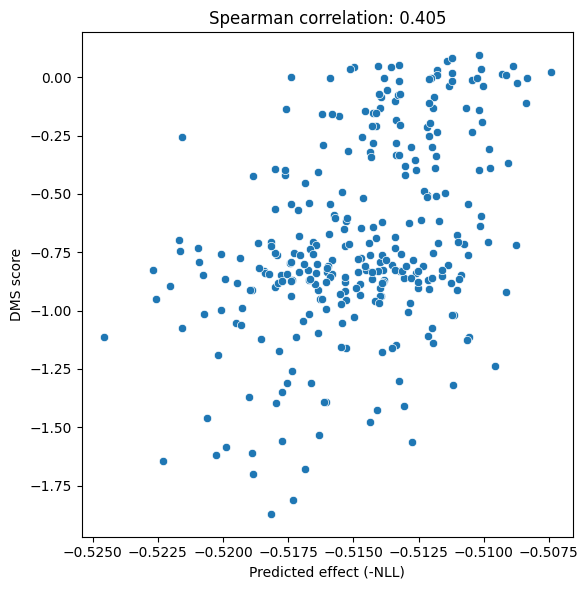

In [7]:
predicted_effect = -nlls
rho = spearmanr(df['DMS_score'], predicted_effect).correlation

fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(x=predicted_effect, y=df['DMS_score'], ax=ax)
ax.set_xlabel('Predicted effect (-NLL)')
ax.set_ylabel('DMS score')
ax.set_title(f'Spearman correlation: {rho:.3f}')
fig.tight_layout()

print(f'Spearman correlation: {rho:.3f}')